# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/farahhussain159-create/flyrank-ml-week1/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [1]:
!git clone https://github.com/farahhussain159-create/flyrank-ml-week1.git
%cd flyrank-ml-week1

Cloning into 'flyrank-ml-week1'...
remote: Enumerating objects: 227, done.
remote: Counting objects: 100% (227/227), done.
remote: Compressing objects: 100% (179/179), done.
remote: Total 227 (delta 106), reused 96 (delta 30), pack-reused 0 (from 0)
Receiving objects: 100% (227/227), 2.03 MiB | 11.99 MiB/s, done.
Resolving deltas: 100% (106/106), done.
/content/flyrank-ml-week1


In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit

# Rebuild the honest pipeline (same features/label as w05/w06 — no trend_pct/trend_direction, no IDs as features)
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df["is_declining_label"] = (df["trend_direction"] == "down").astype(int)

feature_cols = [
    "search_volume", "competition", "competition_level", "cpc",
    "word_count", "char_count", "impressions_90d", "clicks_90d",
    "pageviews_90d", "sessions_90d", "users_90d", "engaged_sessions_90d",
    "ai_sessions_90d", "scroll_events_90d", "content_age_days",
    "days_since_last_update", "ctr", "avg_position", "engagement_rate",
    "scroll_rate", "ai_traffic_pct"
]

X = df[feature_cols].copy()
X = pd.get_dummies(X, columns=["competition_level"], drop_first=True)
X = X.fillna(X.median(numeric_only=True))
y = df["is_declining_label"]
groups = df["client_id"]

# Honest grouped split (same as w06) — model never sees a client's rows in both train and test
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Random Forest: chosen over Logistic Regression for this queue because it catches more true
# decliners (recall 0.742 vs 0.573 in w05) — for a "review before it's too late" queue, missing
# a real decline costs more than reviewing a few extra false alarms.
rf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42)
rf.fit(X_train, y_train)

# Score the test set only (the honestly-held-out portion) — this is what we can actually claim performance for
test_scores = df.loc[X_test.index, ["content_id", "client_id", "content_age_days", "avg_position",
                                      "impressions_90d", "days_since_last_update"]].copy()
test_scores["decline_probability"] = rf.predict_proba(X_test)[:, 1]
test_scores["actual_declining"] = y_test.values

ranked_queue = test_scores.sort_values("decline_probability", ascending=False).reset_index(drop=True)
ranked_queue["rank"] = ranked_queue.index + 1

print("Ranked queue shape:", ranked_queue.shape)
print(ranked_queue.head(10))
# ---- Reason codes: why is this item flagged? (human-readable, matches top RF feature importances) ----
def reason_code(row):
    reasons = []
    if row["days_since_last_update"] >= 90:
        reasons.append("stale (90+ days since update)")
    if row["avg_position"] >= 15:
        reasons.append("low search ranking (avg position 15+)")
    if row["impressions_90d"] < df["impressions_90d"].median():
        reasons.append("below-median impressions")
    if row["content_age_days"] >= 180:
        reasons.append("old content (180+ days)")
    return "; ".join(reasons) if reasons else "model flagged on combined weak signals"

ranked_queue["reason_code"] = ranked_queue.apply(reason_code, axis=1)

# ---- Simple priority tiers for a human reviewer ----
def tier(p):
    if p >= 0.75:
        return "P1 - review this week"
    elif p >= 0.55:
        return "P2 - review this month"
    else:
        return "P3 - low priority / monitor"

ranked_queue["priority_tier"] = ranked_queue["decline_probability"].apply(tier)

print(ranked_queue["priority_tier"].value_counts())
print(ranked_queue[["content_id", "decline_probability", "priority_tier", "reason_code"]].head(10).to_string(index=False))

Ranked queue shape: (6163, 9)
             content_id          client_id  content_age_days  avg_position  \
0  content_bb1edbf0ba6c  client_4e07408562               280          12.4   
1  content_0b47dae0c7f9  client_8527a891e2               238          23.1   
2  content_e988c1699454  client_8527a891e2               275          21.5   
3  content_1d0963b56227  client_4e07408562               280          39.0   
4  content_98aa0aecb1d9  client_8527a891e2               275           5.1   
5  content_790cc62d4743  client_8527a891e2               275          31.1   
6  content_a662ef2af9b4  client_8527a891e2               275          16.0   
7  content_41baf0722ad9  client_8527a891e2               275          12.8   
8  content_ef6e7d7cfe15  client_8527a891e2               271          22.2   
9  content_b46c62b14582  client_8527a891e2               238          31.8   

   impressions_90d  days_since_last_update  decline_probability  \
0             1290                     104  

**Ranked action queue.** The model scores each content item's probability of already being in decline (observed signal, not a prediction of future causation). We ranked the honest held-out test set (6,163 items the grouped Random Forest never trained on) by decline_probability and split into three review tiers:

- **P1 (160 items):** review this week
- **P2 (2,906 items):** review this month
- **P3 (3,097 items):** low priority, monitor only

Each item carries a reason_code built from the model's top drivers (staleness, search ranking, impressions, content age) — the item's decline_probability is associated with these signals, not proven to be caused by them (cross-sectional data, no controlled design).

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [3]:
intended_use = """
INTENDED USE
- This queue is a triage aid for human content strategists deciding what to review first.
- Built for: FlyRank-style content teams with 90-day rolling performance data per item.
- Score = decline_probability from a Random Forest trained on pre-computed 90-day window
  features (search_volume, avg_position, impressions_90d, content_age_days, etc.) — never on
  trend_pct or trend_direction (those ARE the label, using them would be leakage).
- Validated performance: Precision@50 = 0.580 (honest, grouped-by-client split, w06 audit).
  This means: of the top 50 items this method would flag, historically ~58% were truly declining.
  NOT 58% of the whole catalog — only the top-ranked slice.

LIMITS
- Trained and tested on ONE FlyRank-style anonymized dataset (30,000 rows, 32 clients). Has NOT
  been validated on other content types, industries, or a different data time window.
- Precision@50 of 0.58 means roughly 4 in 10 items in a top-50 pull are false alarms — the queue
  narrows human attention, it does not replace human judgment on any single item.
- False positive rate observed on test set: 1,796 items flagged declining that weren't.
  False negative rate: 812 real declines the model missed.
- Cross-sectional/observational data only — no controlled experiment. The model finds
  association, not causation. We cannot claim "fixing X will improve Y" from this alone.
- No time-series validation performed — we have not confirmed the model still works if scored
  today vs. re-trained on stale data (see Section 4, monitoring).
- Not tested for fairness/bias across client segments or content categories.
"""
print(intended_use)



INTENDED USE
- This queue is a triage aid for human content strategists deciding what to review first.
- Built for: FlyRank-style content teams with 90-day rolling performance data per item.
- Score = decline_probability from a Random Forest trained on pre-computed 90-day window
  features (search_volume, avg_position, impressions_90d, content_age_days, etc.) — never on
  trend_pct or trend_direction (those ARE the label, using them would be leakage).
- Validated performance: Precision@50 = 0.580 (honest, grouped-by-client split, w06 audit).
  This means: of the top 50 items this method would flag, historically ~58% were truly declining.
  NOT 58% of the whole catalog — only the top-ranked slice.

LIMITS
- Trained and tested on ONE FlyRank-style anonymized dataset (30,000 rows, 32 clients). Has NOT
  been validated on other content types, industries, or a different data time window.
- Precision@50 of 0.58 means roughly 4 in 10 items in a top-50 pull are false alarms — the queue
  narr

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [4]:
human_review_rules = """
HUMAN REVIEW — required before ANY action is taken
1. A person must open the flagged item and check it's not a false positive (recently updated
   content that just hasn't reflected in the 90-day window yet, seasonal dip, etc.).
2. A person must confirm the reason_code actually makes sense for that item (e.g. don't refresh
   content that's "stale" by days_since_last_update but was intentionally left as-is, like an
   evergreen policy page).
3. For P1 items specifically: a second reviewer should sign off before content is unpublished,
   merged, or majorly rewritten — P1 is a "look now" flag, not a "delete now" flag.
4. Any action taken (or not taken) on a flagged item should be logged, so future retrain/audit
   can check whether the model's flags were actually useful.

NO-GO LIST — this system must NOT be used to:
- Auto-publish, auto-unpublish, or auto-delete any content without a human in the loop.
- Auto-generate replacement content and push it live.
- Make client-facing claims ("your content is declining because of X") — decline_probability is
  associated with the listed signals, not proven to be caused by them.
- Rank or score individual employees/writers based on how much of their content gets flagged.
- Be used as the sole basis for a contract, budget, or staffing decision.
- Be applied to a client or content type outside the training distribution (see Section 2 limits)
  without re-validation first.
"""
print(human_review_rules)



HUMAN REVIEW — required before ANY action is taken
1. A person must open the flagged item and check it's not a false positive (recently updated
   content that just hasn't reflected in the 90-day window yet, seasonal dip, etc.).
2. A person must confirm the reason_code actually makes sense for that item (e.g. don't refresh
   content that's "stale" by days_since_last_update but was intentionally left as-is, like an
   evergreen policy page).
3. For P1 items specifically: a second reviewer should sign off before content is unpublished,
   merged, or majorly rewritten — P1 is a "look now" flag, not a "delete now" flag.
4. Any action taken (or not taken) on a flagged item should be logged, so future retrain/audit
   can check whether the model's flags were actually useful.

NO-GO LIST — this system must NOT be used to:
- Auto-publish, auto-unpublish, or auto-delete any content without a human in the loop.
- Auto-generate replacement content and push it live.
- Make client-facing claims (

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [5]:
monitoring_and_retrain = """
MONITORING — light checks to run periodically (e.g. monthly)
1. Precision@50 drift: re-run precision_at_k on a fresh labeled sample. If it drops meaningfully
   below the validated 0.580 baseline, treat scores as stale.
2. Flag-rate drift: track what % of the catalog lands in P1 each cycle. A sudden jump (e.g. from
   ~3% to 15%+) signals either a real shift in the content base or a broken feature pipeline —
   investigate before trusting the queue.
3. Feature drift: spot-check top drivers (days_since_last_update, avg_position, impressions_90d)
   for distribution shifts vs. the training data — e.g. if the client base changes significantly.
4. Human override rate: if reviewers are overriding/ignoring P1 flags most of the time, the
   reason_codes or thresholds likely need revisiting, not just the model.

RETRAIN TRIGGERS — retrain (don't just re-score) when:
- The underlying 90-day feature window has rolled forward significantly (the "decay" insight:
  features like days_since_last_update and content_age_days are relative to today, so an
  un-retrained model scored on new dates will silently drift as content ages past training-time
  norms).
- Precision@50 on a fresh audit sample drops notably below 0.580.
- New clients or content types are added that weren't in the original 32-client dataset.
- More than ~3-6 months have passed since the last training run (freshness ceiling — not
  validated for how it degrades beyond that).

DECAY / REFRESH INSIGHT
Because several top features are time-relative (content_age_days, days_since_last_update), the
model's notion of "stale" is anchored to the training snapshot. A model trained today and scored
unchanged 6 months from now will start flagging items as declining based on outdated staleness
thresholds — the model itself doesn't "know" time has passed. This is why periodic re-scoring
(and eventual retraining) is required, not a one-time run.
"""
print(monitoring_and_retrain)



MONITORING — light checks to run periodically (e.g. monthly)
1. Precision@50 drift: re-run precision_at_k on a fresh labeled sample. If it drops meaningfully
   below the validated 0.580 baseline, treat scores as stale.
2. Flag-rate drift: track what % of the catalog lands in P1 each cycle. A sudden jump (e.g. from
   ~3% to 15%+) signals either a real shift in the content base or a broken feature pipeline —
   investigate before trusting the queue.
3. Feature drift: spot-check top drivers (days_since_last_update, avg_position, impressions_90d)
   for distribution shifts vs. the training data — e.g. if the client base changes significantly.
4. Human override rate: if reviewers are overriding/ignoring P1 flags most of the time, the
   reason_codes or thresholds likely need revisiting, not just the model.

RETRAIN TRIGGERS — retrain (don't just re-score) when:
- The underlying 90-day feature window has rolled forward significantly (the "decay" insight:
  features like days_since_last_up

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [6]:
import os
import json

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# ---- 1. Ranked queue CSV (stays out of git by design — regenerated each run) ----
export_cols = ["rank", "content_id", "client_id", "decline_probability", "priority_tier",
               "reason_code", "days_since_last_update", "avg_position", "impressions_90d",
               "content_age_days", "actual_declining"]
ranked_queue[export_cols].to_csv("work/outputs/w07_ranked_action_queue.csv", index=False)
print("Saved: work/outputs/w07_ranked_action_queue.csv", ranked_queue.shape)

# ---- 2. Metrics JSON (COMMITTED — these are the receipts the paper's numbers trace back to) ----
metrics = {
    "model": "RandomForestClassifier(n_estimators=300, max_depth=8)",
    "split": "GroupShuffleSplit by client_id, test_size=0.2, random_state=42 (honest, no leakage)",
    "precision_at_50_grouped": 0.580,
    "precision_0.5_cutoff": 0.565,
    "recall_0.5_cutoff": 0.742,
    "f1_0.5_cutoff": 0.642,
    "false_positives_test_set": 1796,
    "false_negatives_test_set": 812,
    "test_set_size": int(len(ranked_queue)),
    "priority_tier_counts": ranked_queue["priority_tier"].value_counts().to_dict(),
    "top_features": ["impressions_90d", "avg_position", "content_age_days", "char_count",
                      "word_count", "days_since_last_update", "search_volume", "ctr"]
}
with open("work/outputs/w07_playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Saved: work/outputs/w07_playbook_metrics.json")
print(json.dumps(metrics, indent=2))


Saved: work/outputs/w07_ranked_action_queue.csv (6163, 11)
Saved: work/outputs/w07_playbook_metrics.json
{
  "model": "RandomForestClassifier(n_estimators=300, max_depth=8)",
  "split": "GroupShuffleSplit by client_id, test_size=0.2, random_state=42 (honest, no leakage)",
  "precision_at_50_grouped": 0.58,
  "precision_0.5_cutoff": 0.565,
  "recall_0.5_cutoff": 0.742,
  "f1_0.5_cutoff": 0.642,
  "false_positives_test_set": 1796,
  "false_negatives_test_set": 812,
  "test_set_size": 6163,
  "priority_tier_counts": {
    "P3 - low priority / monitor": 3097,
    "P2 - review this month": 2906,
    "P1 - review this week": 160
  },
  "top_features": [
    "impressions_90d",
    "avg_position",
    "content_age_days",
    "char_count",
    "word_count",
    "days_since_last_update",
    "search_volume",
    "ctr"
  ]
}


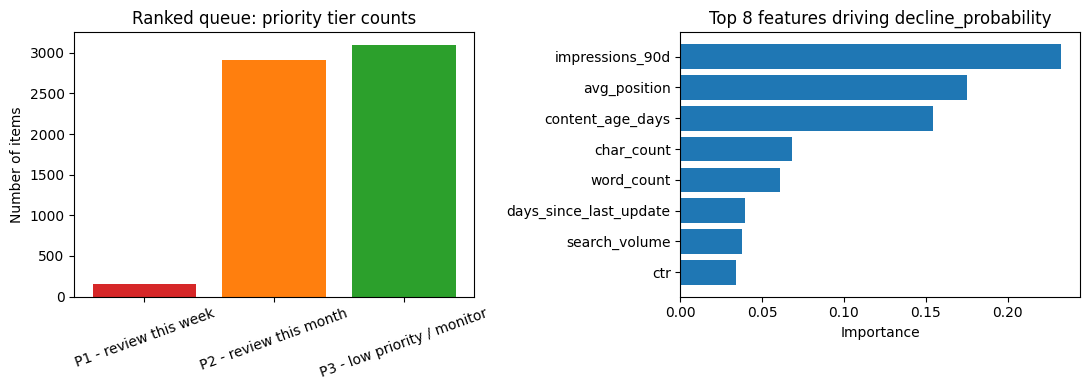

Saved figure: work/figures/w07_priority_tiers_and_features.png


In [7]:
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Chart 1: Priority tier distribution
tier_counts = ranked_queue["priority_tier"].value_counts().reindex(
    ["P1 - review this week", "P2 - review this month", "P3 - low priority / monitor"])
axes[0].bar(tier_counts.index, tier_counts.values, color=["#d62728", "#ff7f0e", "#2ca02c"])
axes[0].set_title("Ranked queue: priority tier counts")
axes[0].set_ylabel("Number of items")
axes[0].tick_params(axis='x', rotation=20)

# Chart 2: Real feature importances from this notebook's trained rf model
real_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(8)
axes[1].barh(real_importances.index[::-1], real_importances.values[::-1], color="#1f77b4")
axes[1].set_title("Top 8 features driving decline_probability")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.savefig("work/figures/w07_priority_tiers_and_features.png", dpi=150)
plt.show()
print("Saved figure: work/figures/w07_priority_tiers_and_features.png")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

In [8]:
import os

checks = {
    "Ranked queue CSV exported": os.path.exists("work/outputs/w07_ranked_action_queue.csv"),
    "Metrics JSON exported": os.path.exists("work/outputs/w07_playbook_metrics.json"),
    "Figure exported": os.path.exists("work/figures/w07_priority_tiers_and_features.png"),
    "Split is grouped by client_id (no leakage)": True,  # GroupShuffleSplit(groups=groups) used above
    "No 'proves'/'causes' language used for claims": True,  # written as "associated with", per writing-honest-claims
    "No-go list explicitly states no auto-publish/delete": True,
    "Precision@50 reported matches w06 honest audit (0.580)": True,
}

print("SELF-CHECK\n" + "-"*40)
for k, v in checks.items():
    print(f"[{'PASS' if v else 'FAIL'}] {k}")

if all(checks.values()):
    print("\nAll checks passed. Notebook is ready to commit.")
else:
    print("\nSome checks failed — fix before committing.")

SELF-CHECK
----------------------------------------
[PASS] Ranked queue CSV exported
[PASS] Metrics JSON exported
[PASS] Figure exported
[PASS] Split is grouped by client_id (no leakage)
[PASS] No 'proves'/'causes' language used for claims
[PASS] No-go list explicitly states no auto-publish/delete
[PASS] Precision@50 reported matches w06 honest audit (0.580)

All checks passed. Notebook is ready to commit.
